# Basic CNN for traffic sign recognition
## Christian Igel, 2022

This notebook provides a template for a small CNN for the German Traffic Sign Recognition Benchmark. The data is described in:

Johannes Stallkamp, Marc Schlipsing, Jan Salmen, and Christian Igel. Man vs. Computer: Benchmarking Machine Learning Algorithms for Traffic Sign Recognition. *Neural Networks* **32**, pp. 323-332, 2012

This notebook is a template, without modification the model does not even come close to the state-of-the-art. 

Please [contact me](mailto:igel@diku.dk) if you have suggestions for improving the notebook.

Do the imports first:

In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np

import torch 
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data.dataset import Dataset
from torchvision.datasets.utils import download_url, extract_archive

Check if a GPU is available:

In [16]:
gpu = torch.cuda.is_available()
device = torch.device("cuda:0" if gpu else "cpu")
print("device:", device)

device: cpu


The GTSRB data wrapped in a `Dataset`. This is implemented in the file `GTSRBTrafficSigns.py`. Let's import the class:

In [17]:
from GTSRBTrafficSigns import GTSRBTrafficSigns

In [18]:
dataset_train = GTSRBTrafficSigns()

Using existing ./GTSRB/train


Define the data loader for training:

In [19]:
batch_size = 128
generator_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4)

In [20]:
print("Number of training patterns:", dataset_train.__len__())

Number of training patterns: 39209


Let's visualize some input images. This visualization is very important, among others to verify that the data augmentation works as expected.

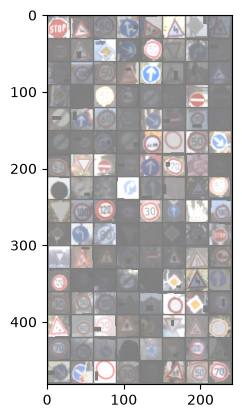

In [21]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(generator_train)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

Let's look at each image in the batch with its label:

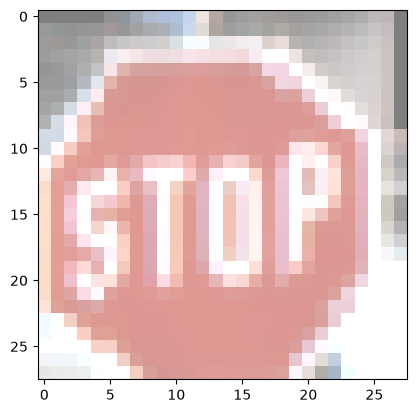

14 




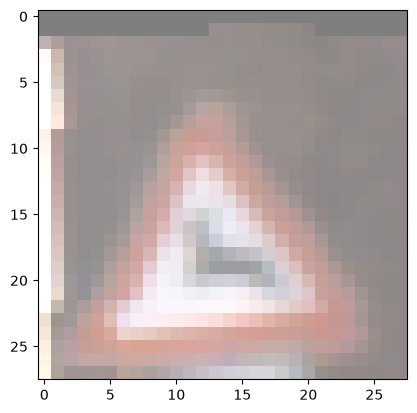

31 




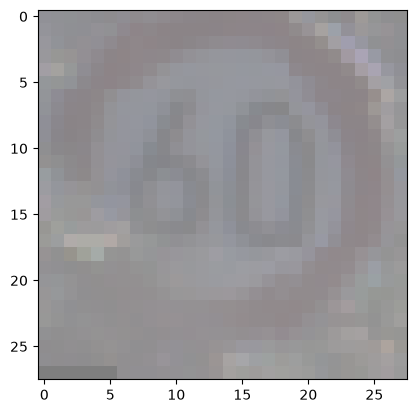

3 




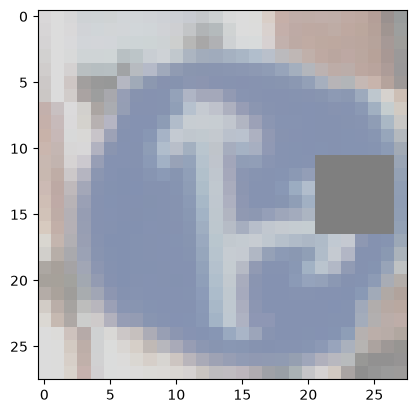

36 




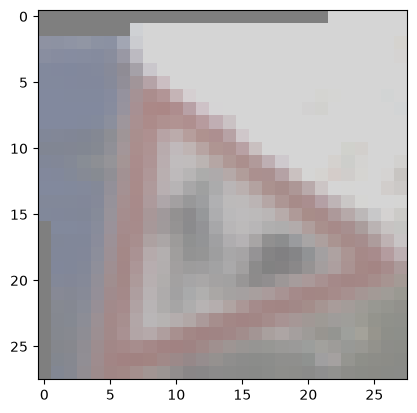

25 




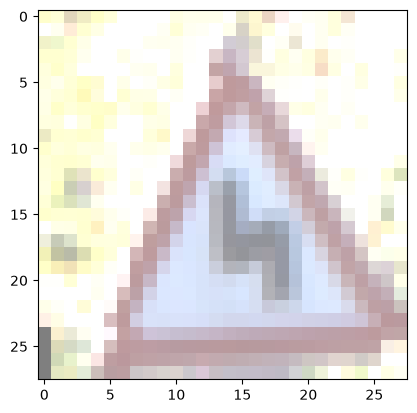

21 




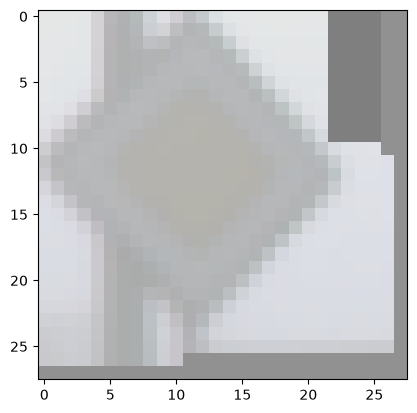

12 




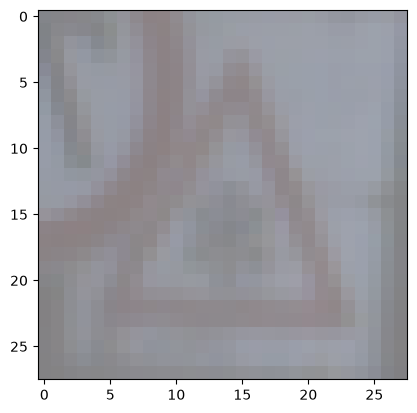

30 




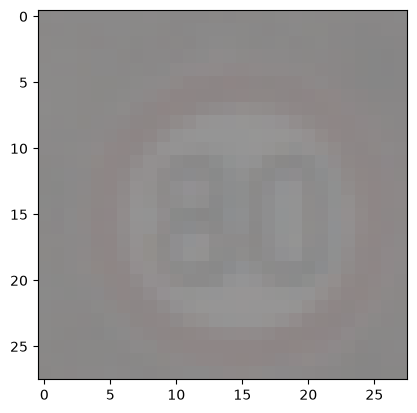

5 




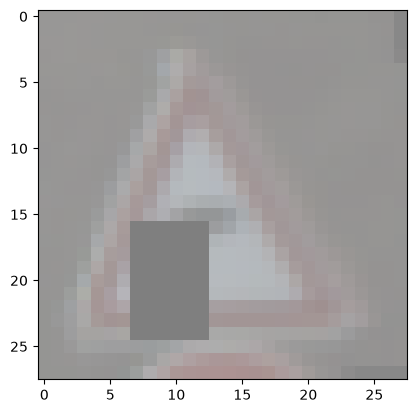

20 




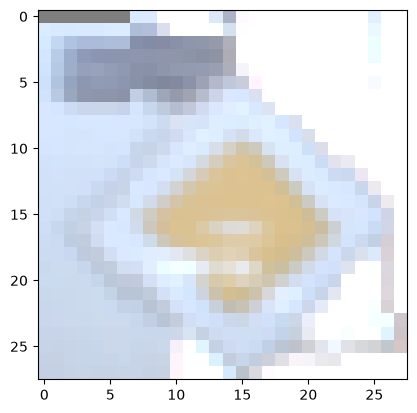

12 




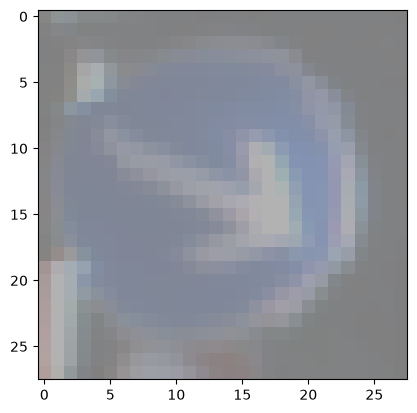

38 




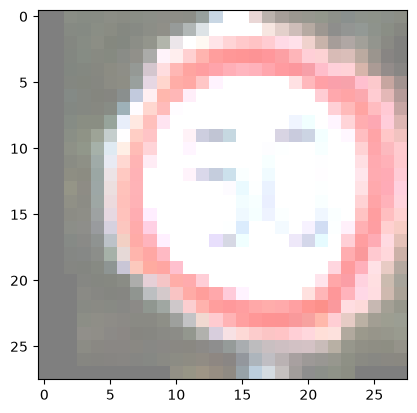

2 




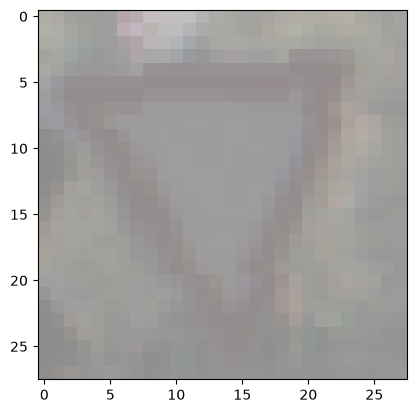

13 




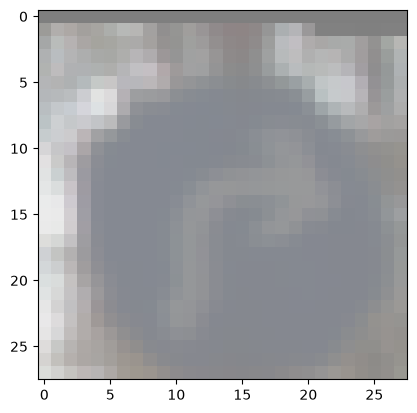

33 




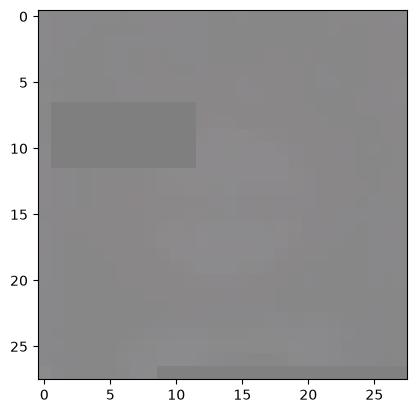

9 




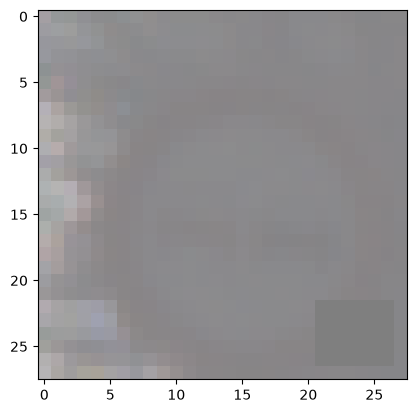

9 




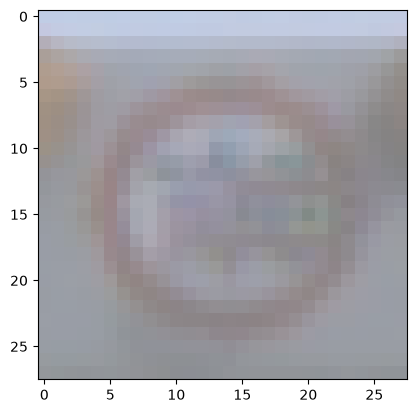

7 




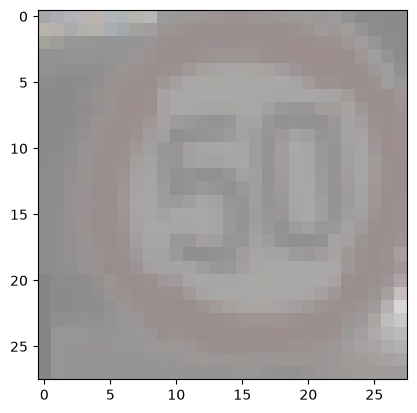

2 




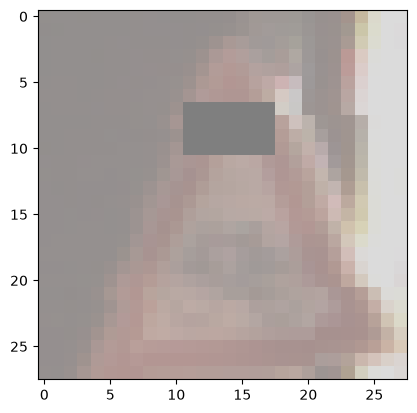

29 




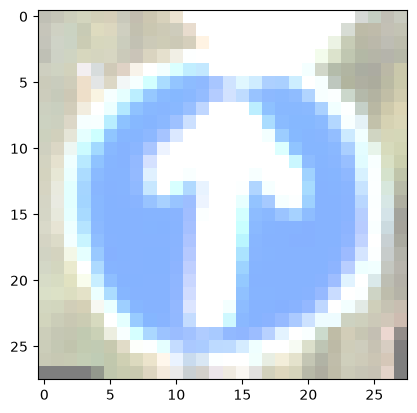

35 




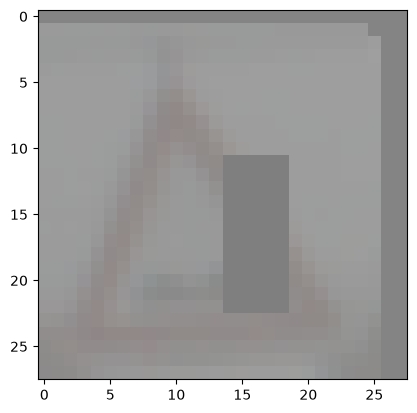

22 




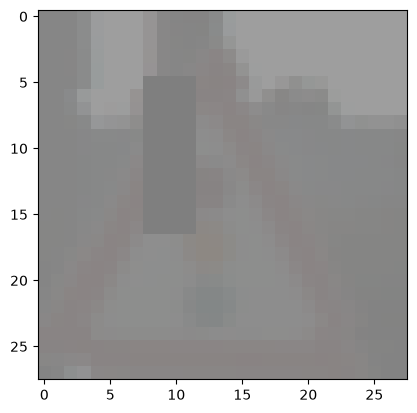

26 




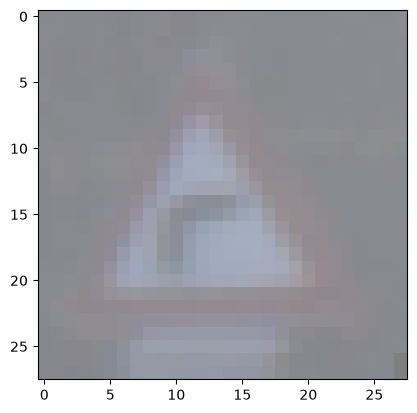

20 




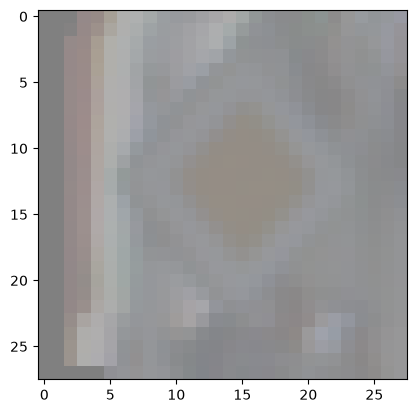

12 




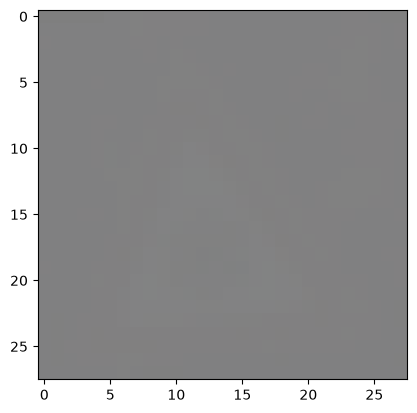

30 




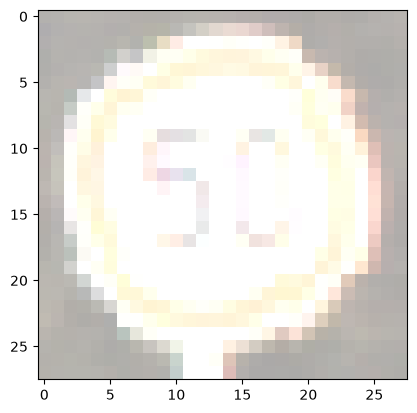

2 




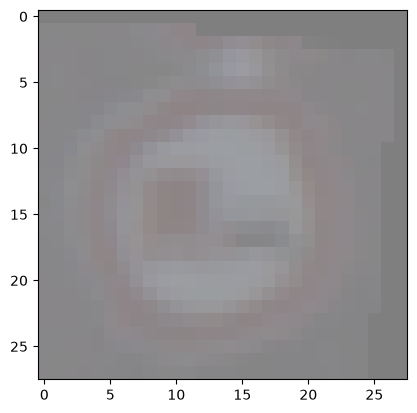

10 




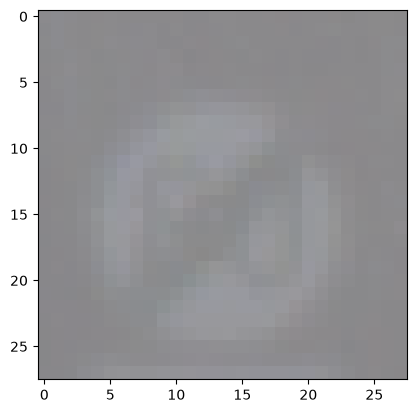

6 




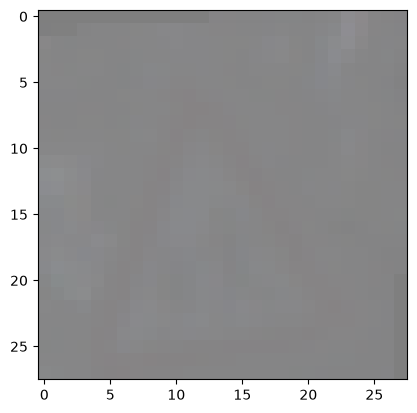

28 




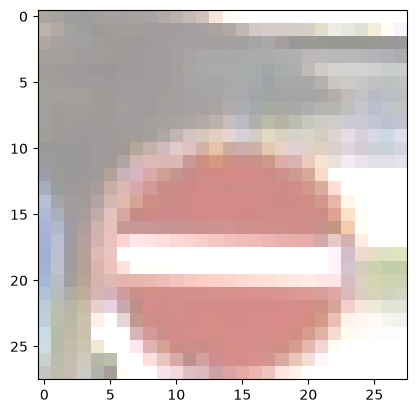

17 




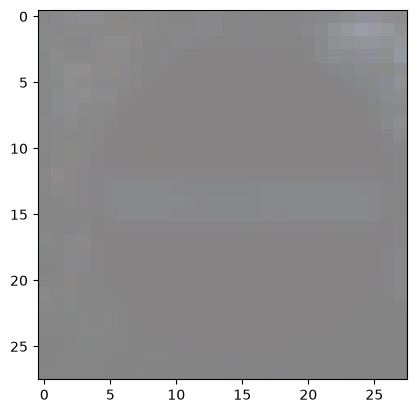

17 




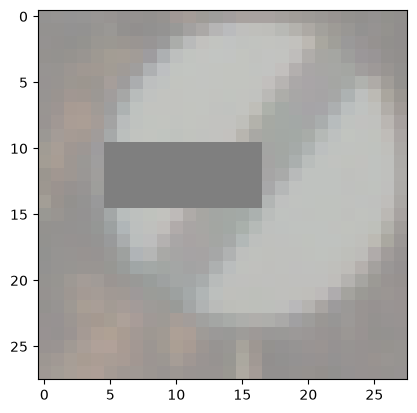

32 




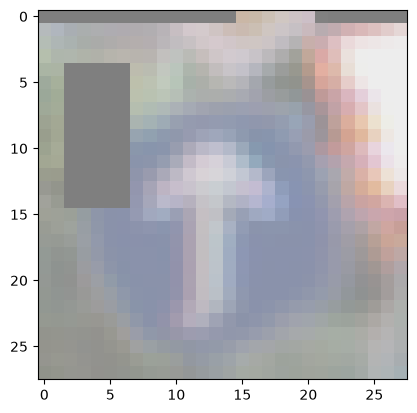

35 




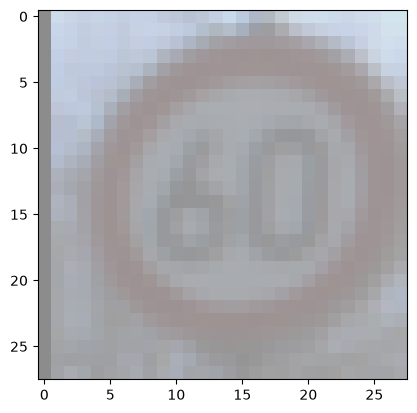

3 




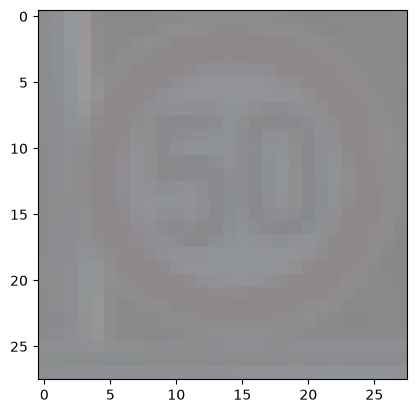

2 




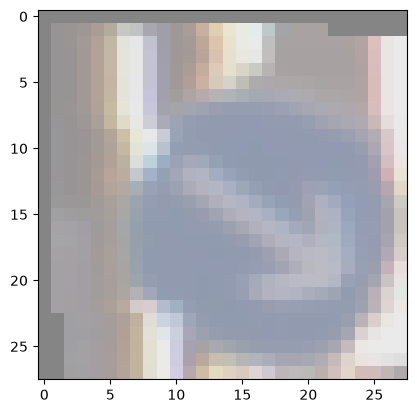

38 




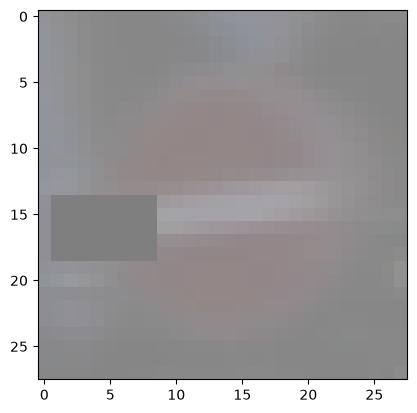

17 




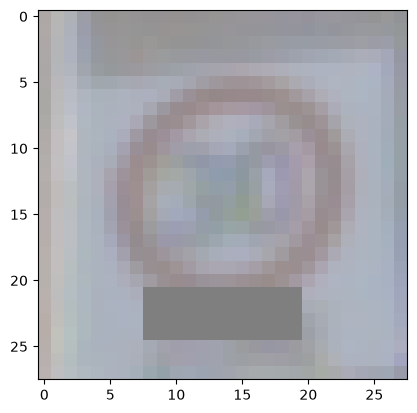

1 




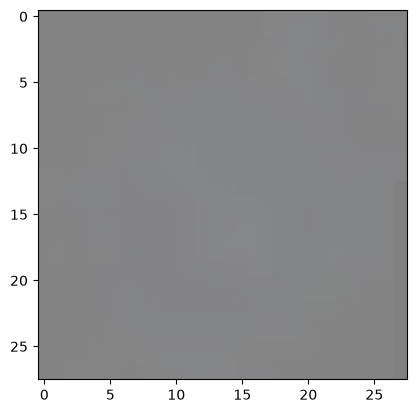

38 




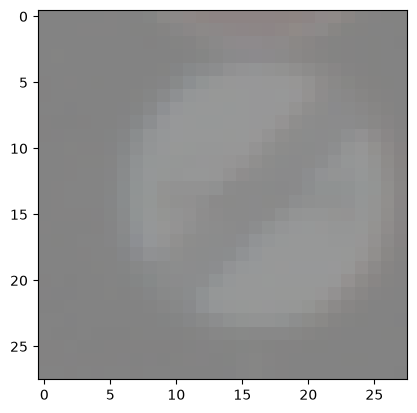

41 




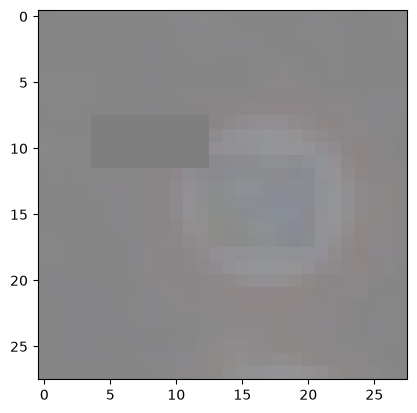

8 




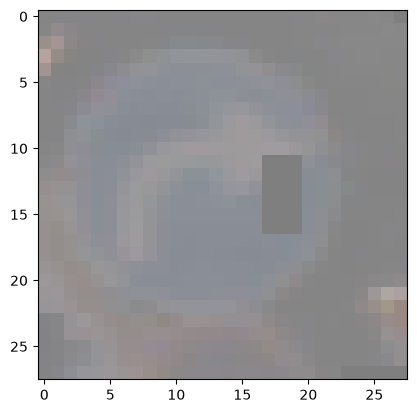

33 




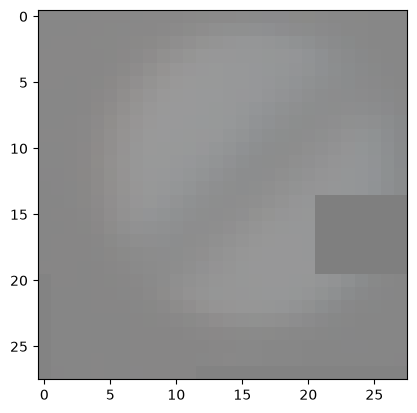

32 




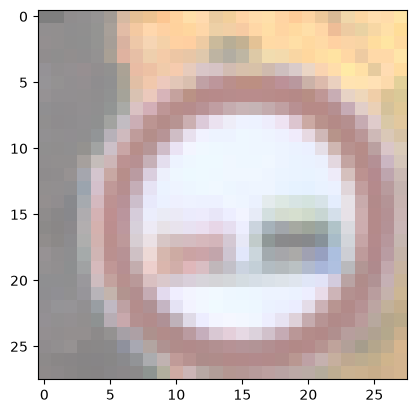

9 




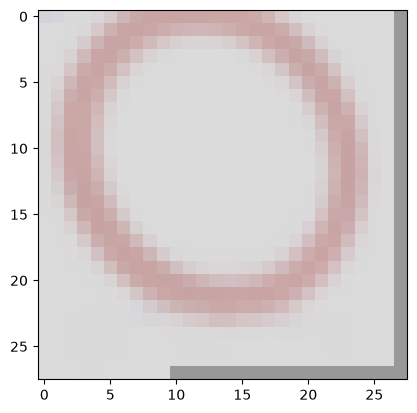

15 




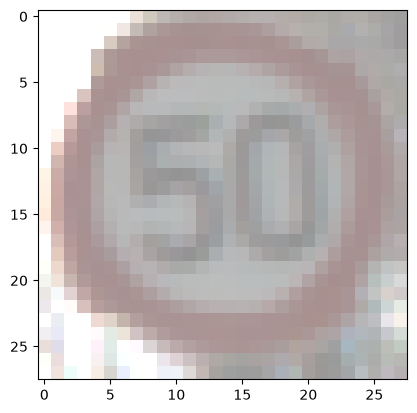

2 




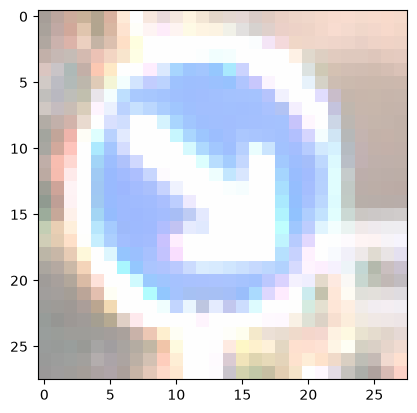

38 




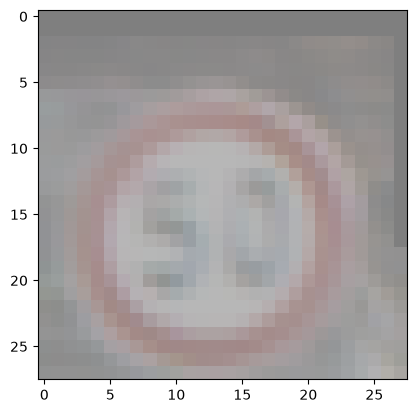

2 




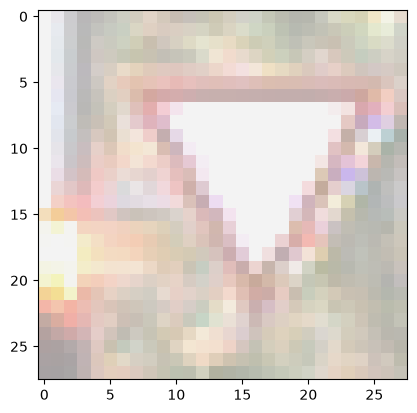

13 




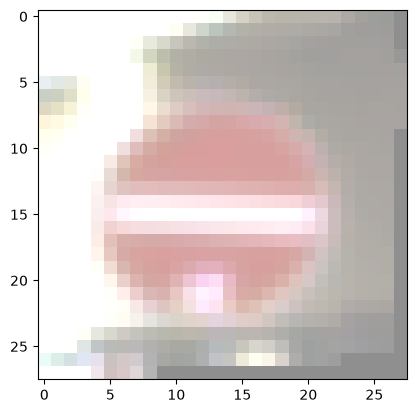

17 




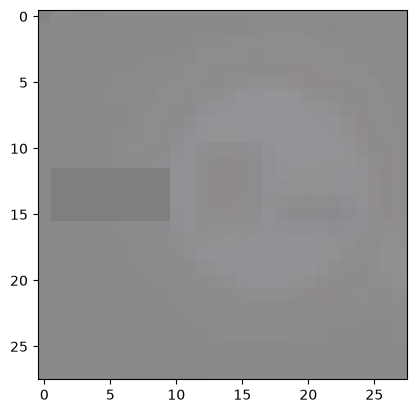

10 




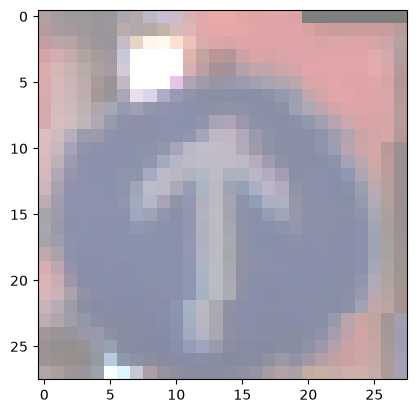

35 




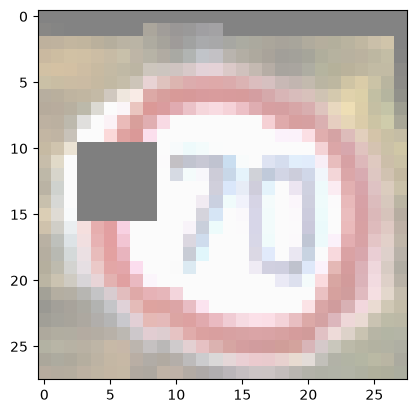

4 




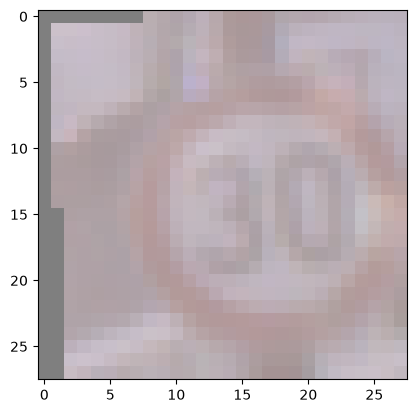

1 




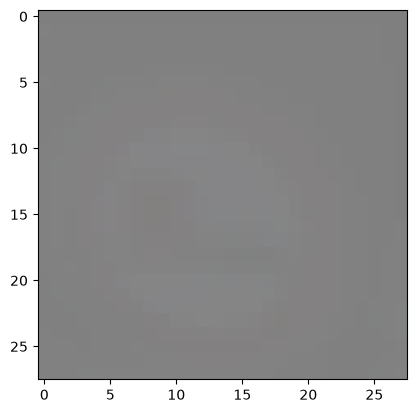

10 




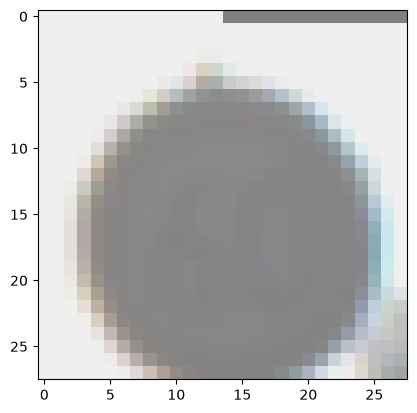

3 




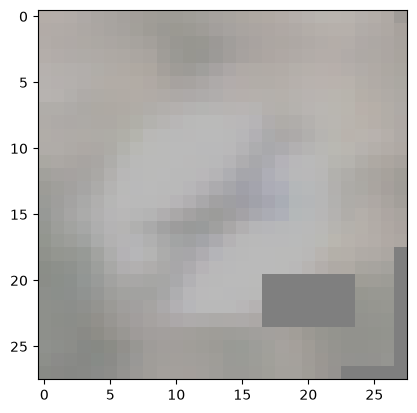

41 




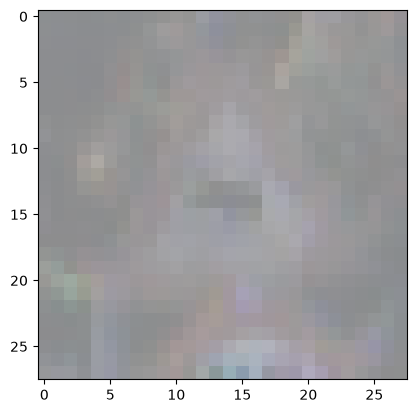

23 




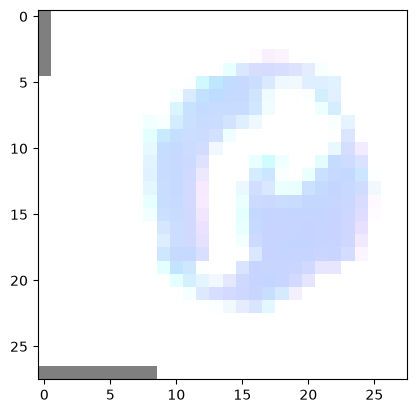

33 




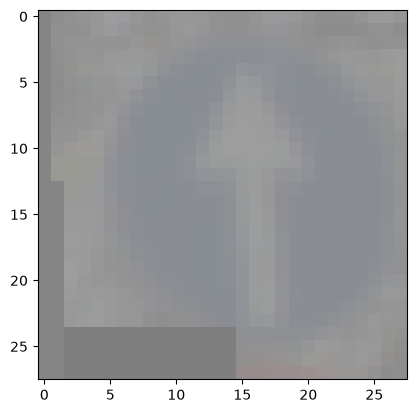

35 




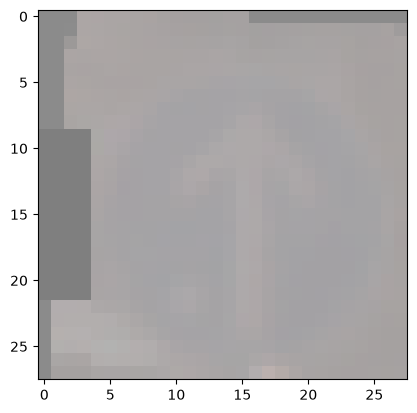

35 




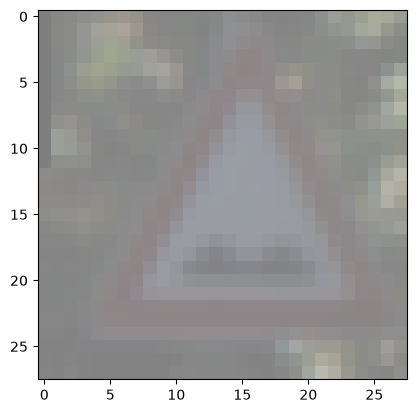

22 




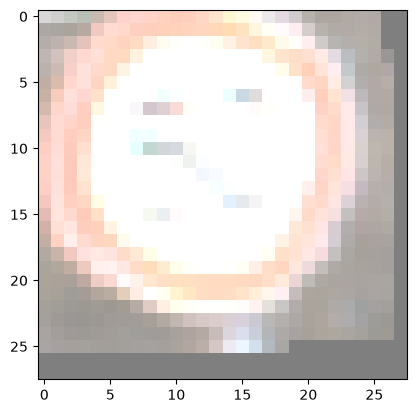

2 




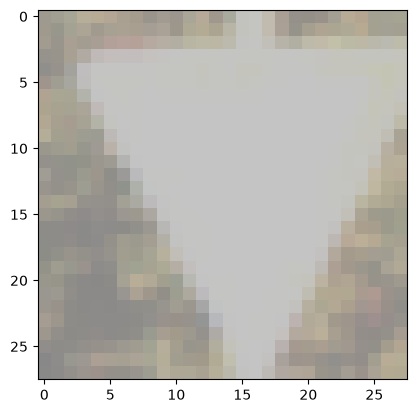

13 




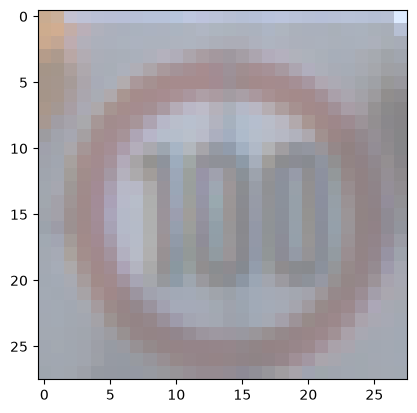

7 




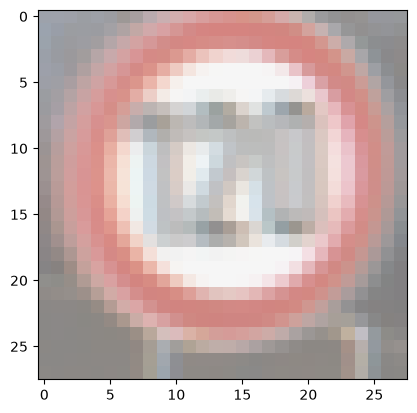

8 




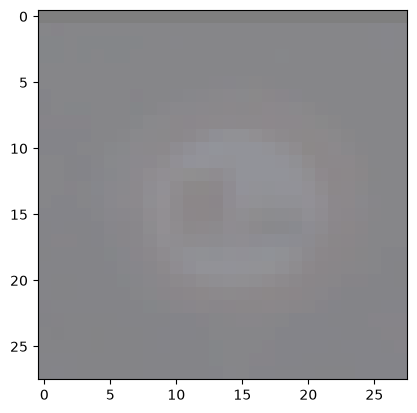

10 




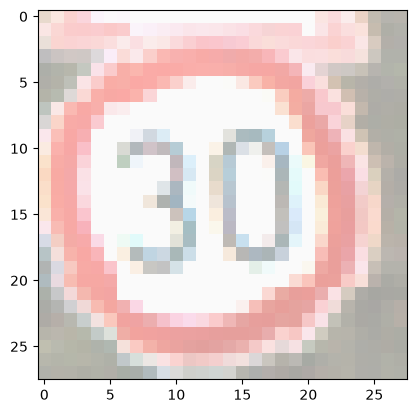

1 




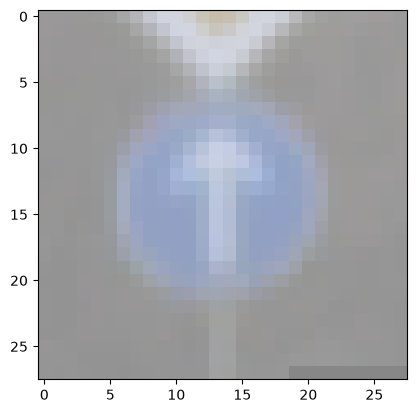

35 




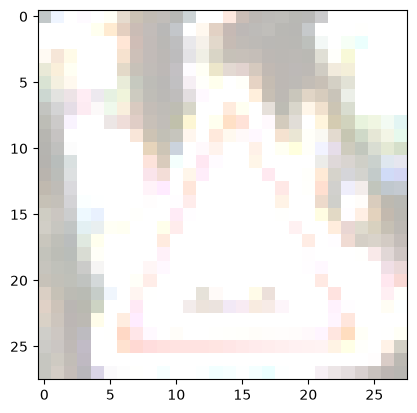

22 




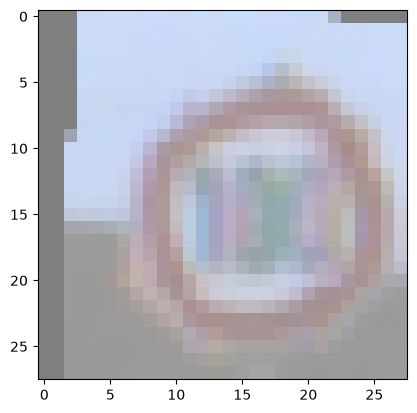

7 




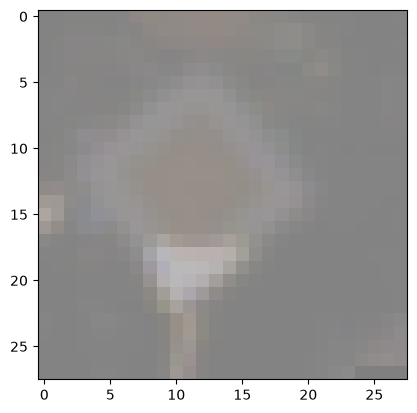

12 




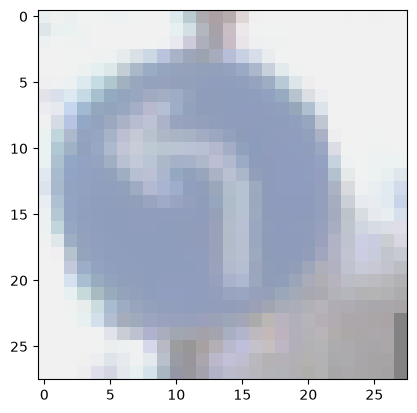

34 




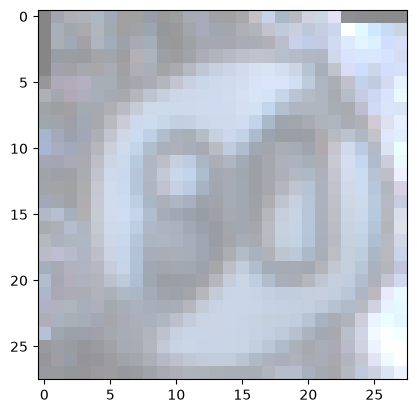

6 




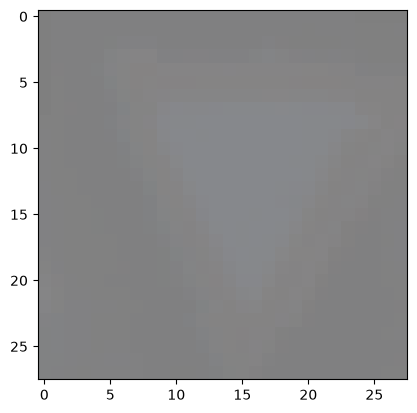

13 




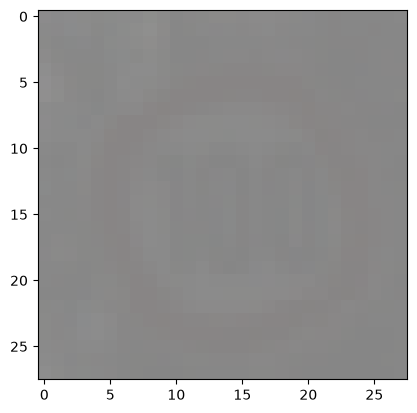

7 




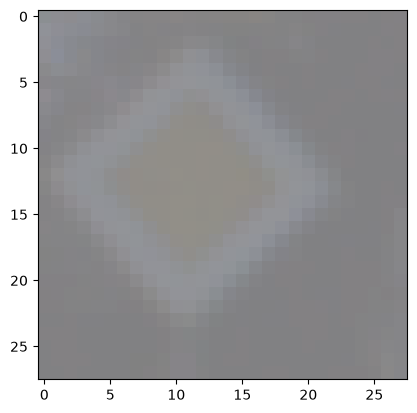

12 




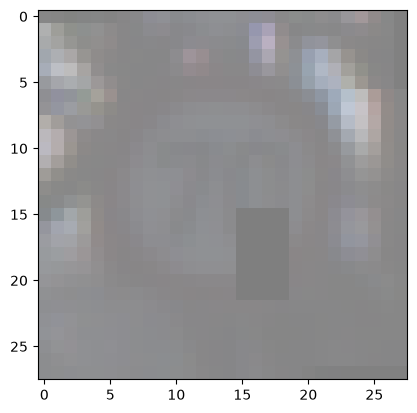

4 




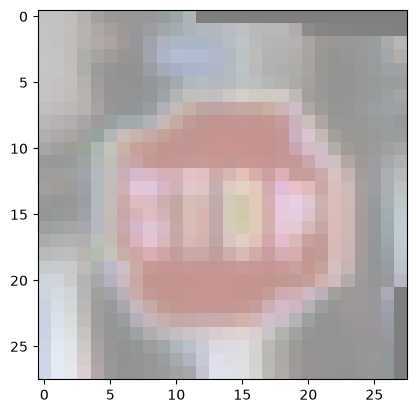

14 




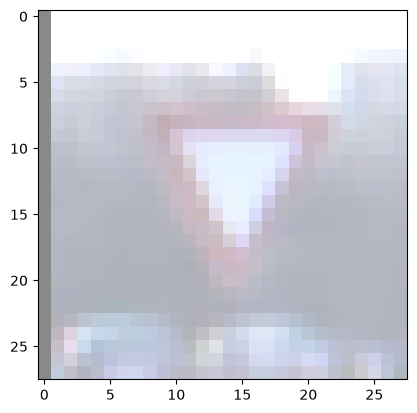

13 




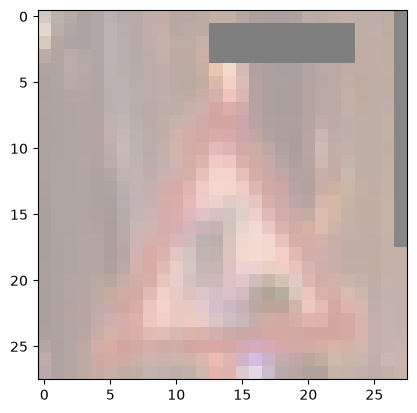

25 




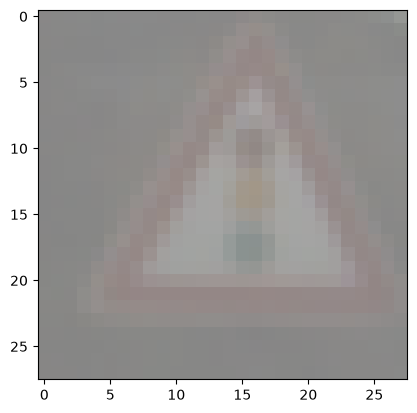

26 




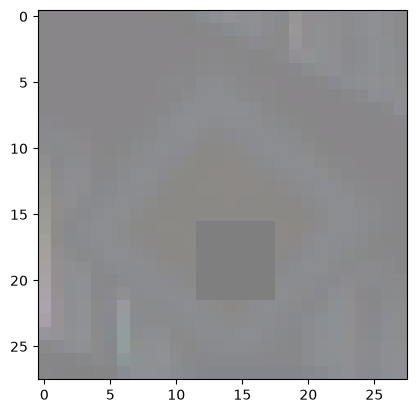

12 




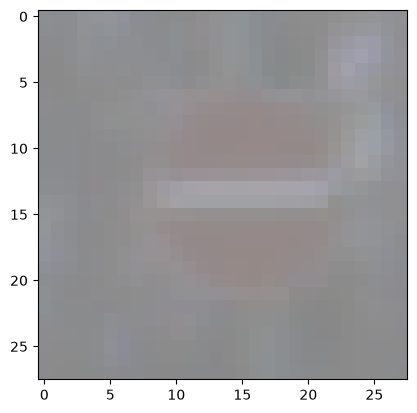

17 




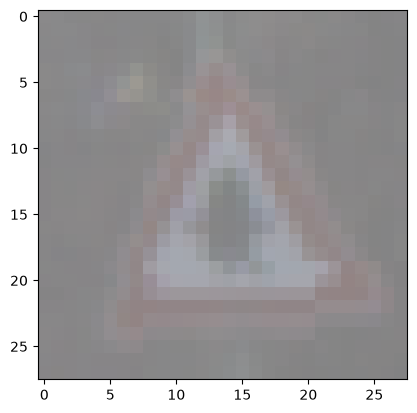

11 




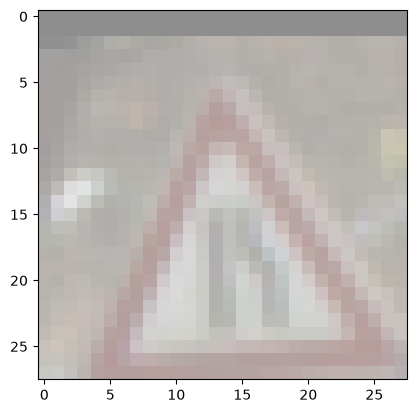

24 




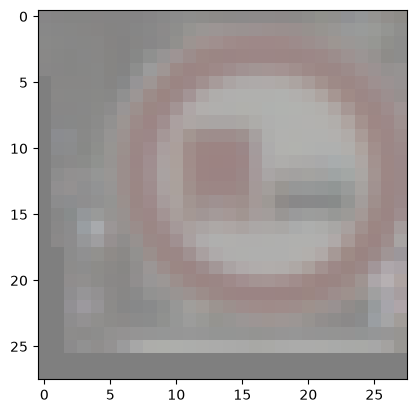

10 




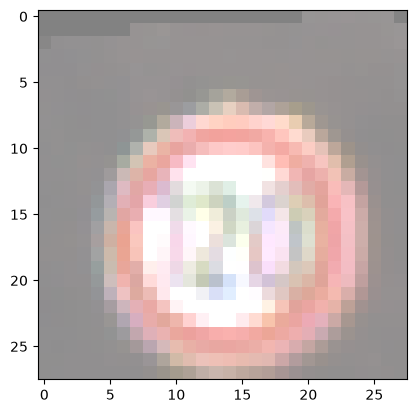

8 




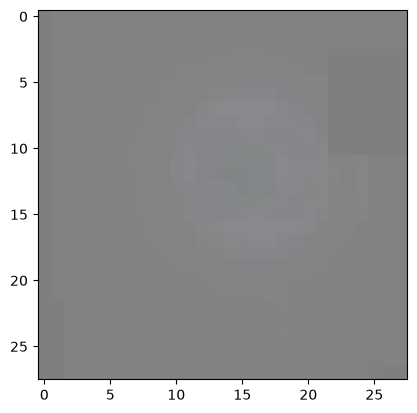

5 




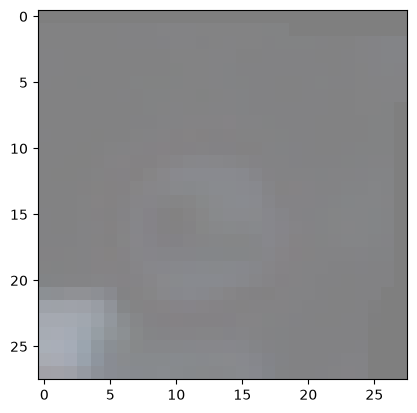

10 




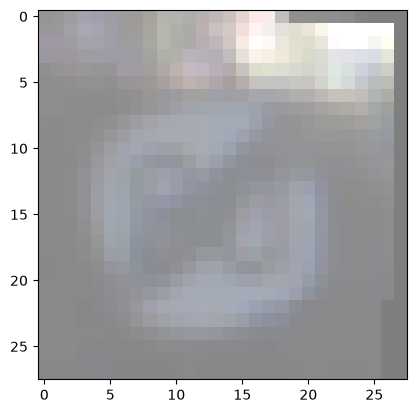

6 




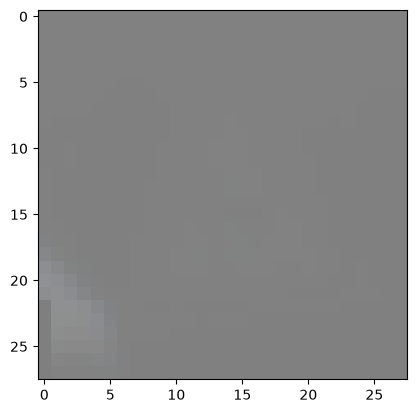

23 




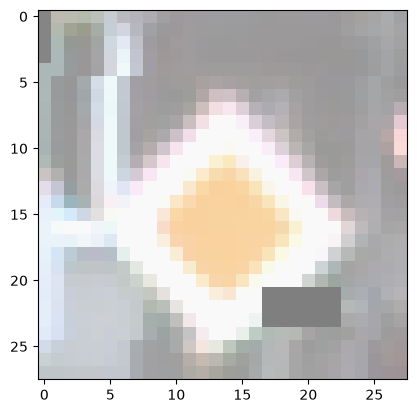

12 




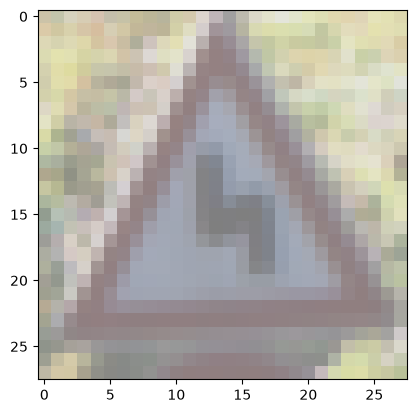

21 




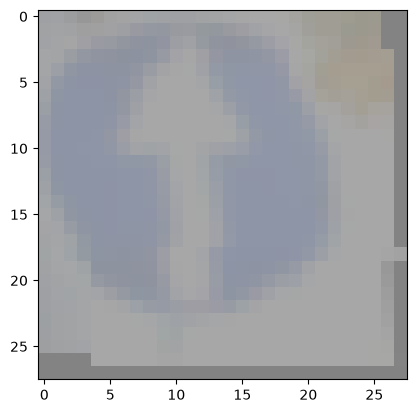

35 




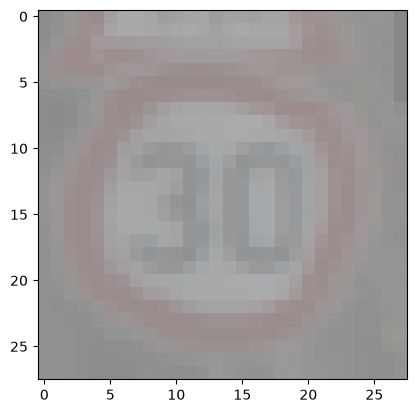

1 




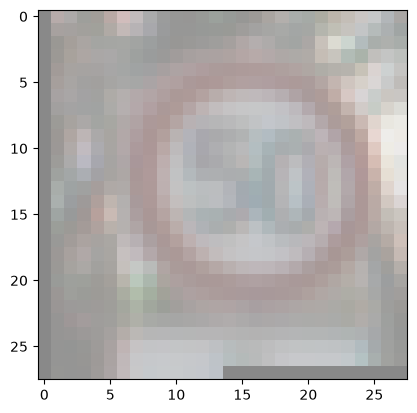

2 




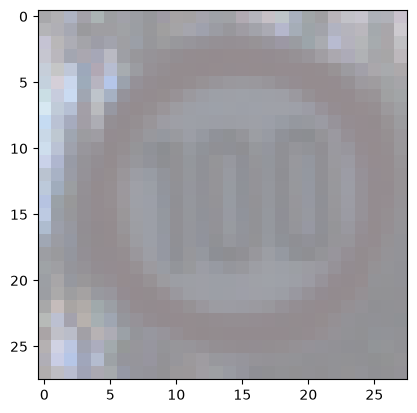

7 




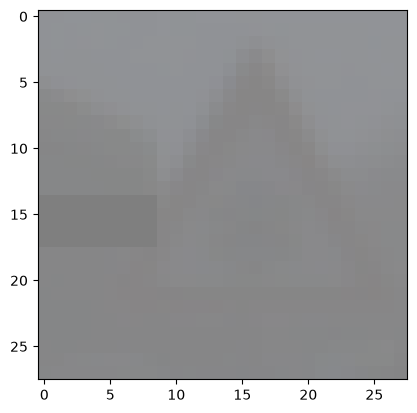

30 




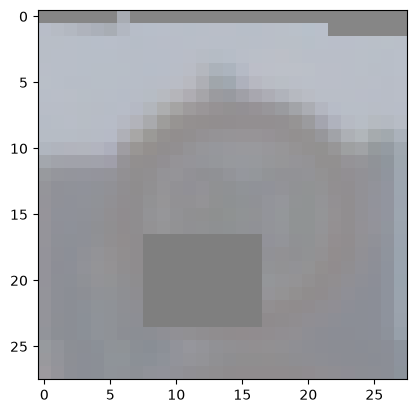

5 




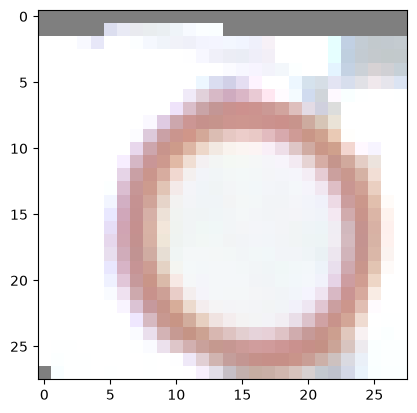

15 




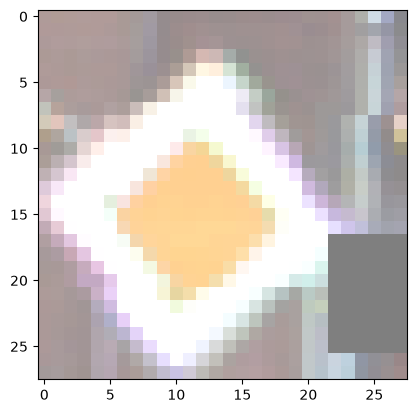

12 




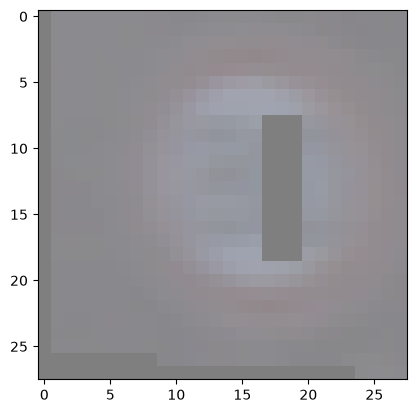

5 




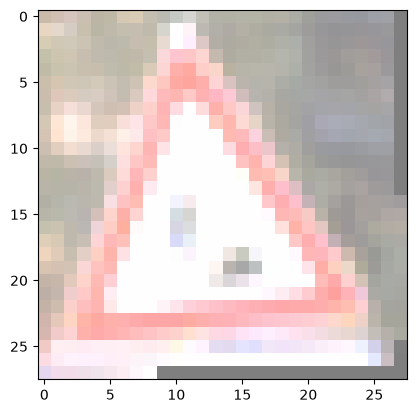

25 




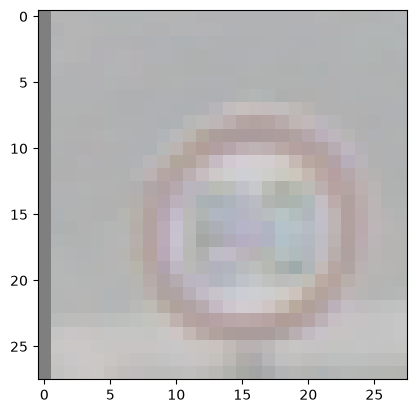

5 




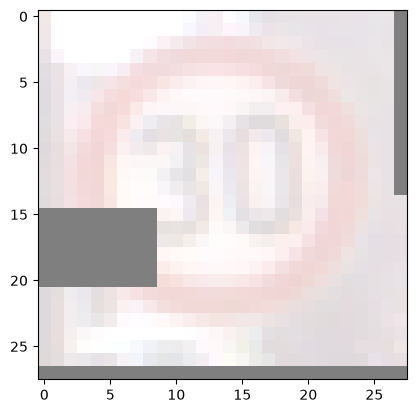

1 




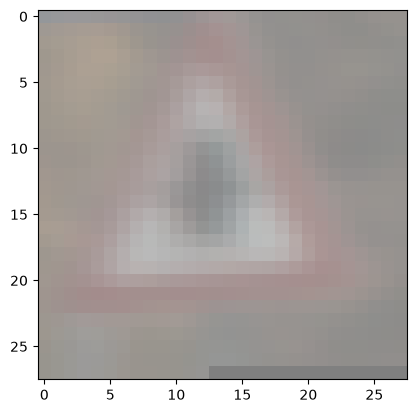

11 




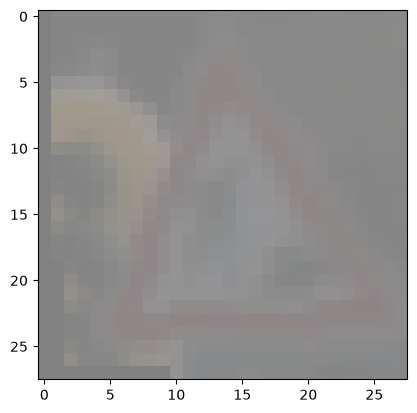

25 




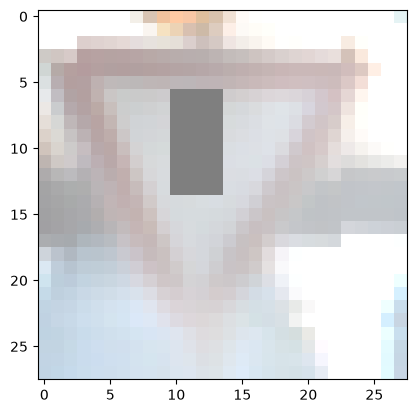

13 




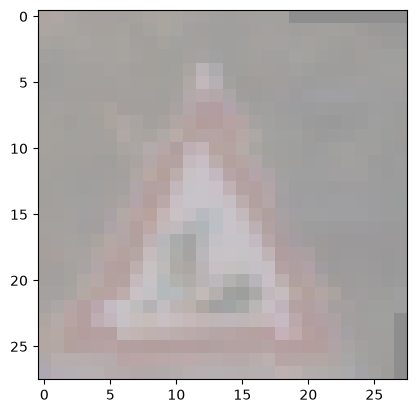

25 




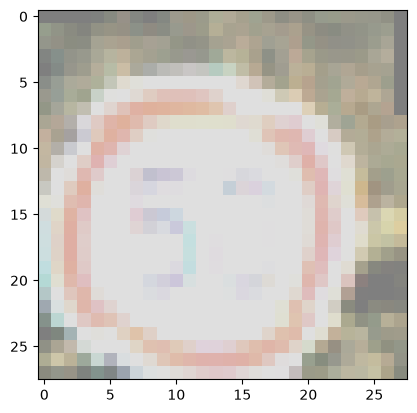

2 




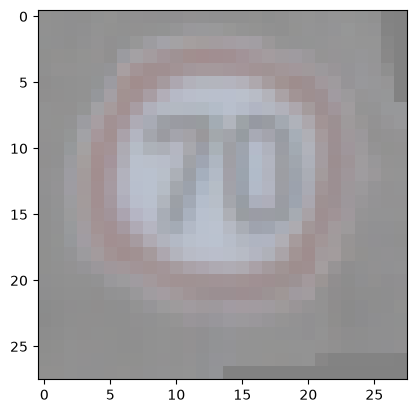

4 




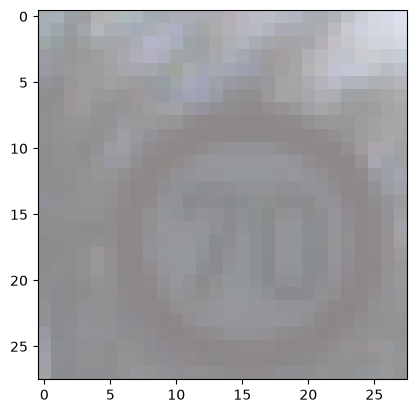

4 




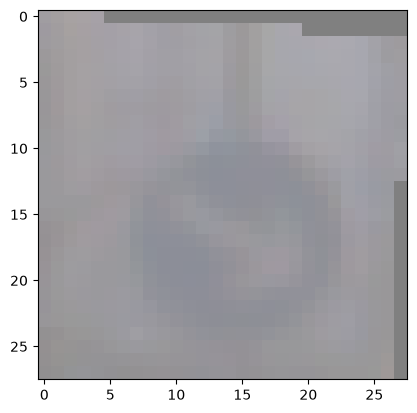

38 




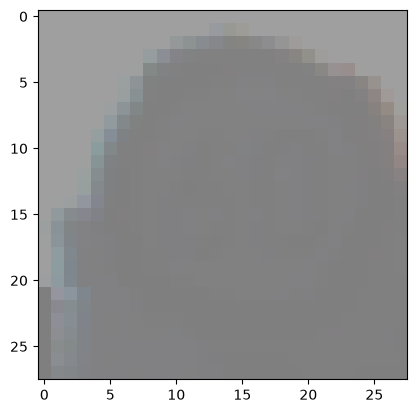

3 




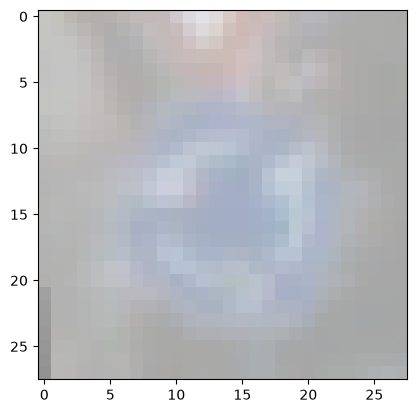

40 




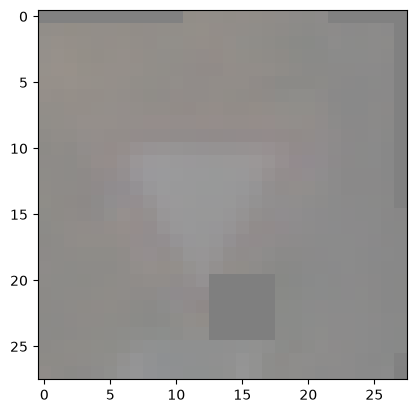

13 




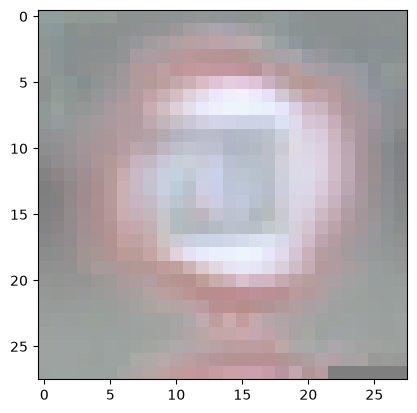

8 




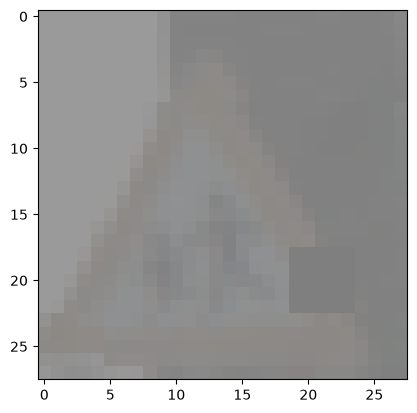

28 




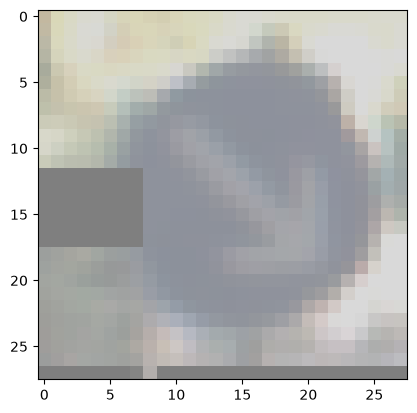

38 




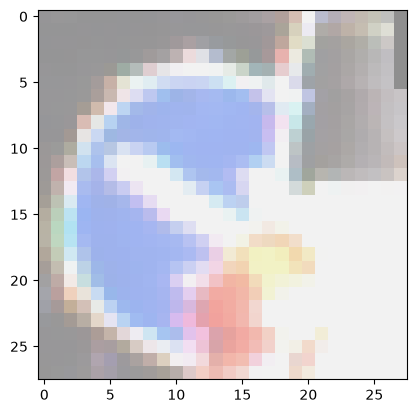

38 




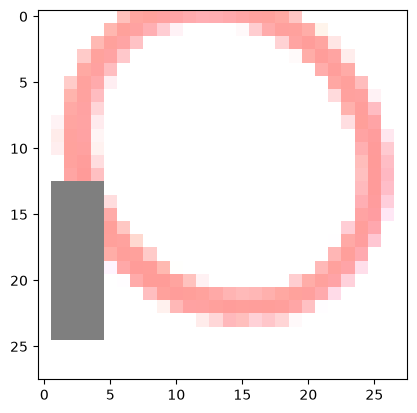

15 




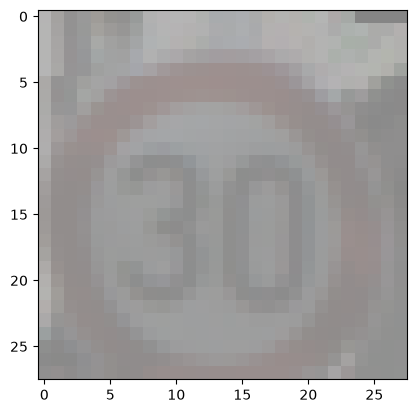

1 




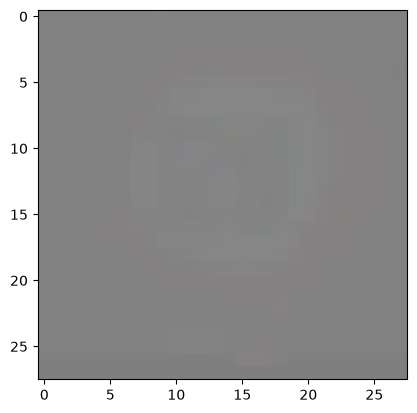

8 




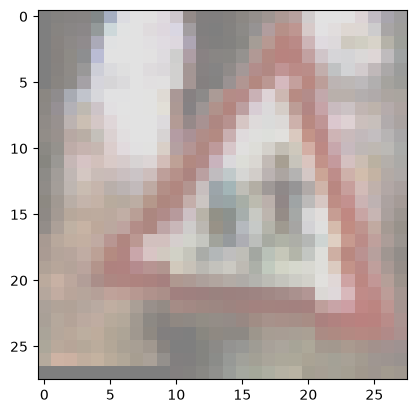

28 




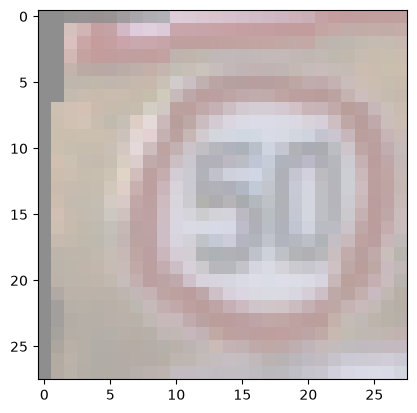

2 




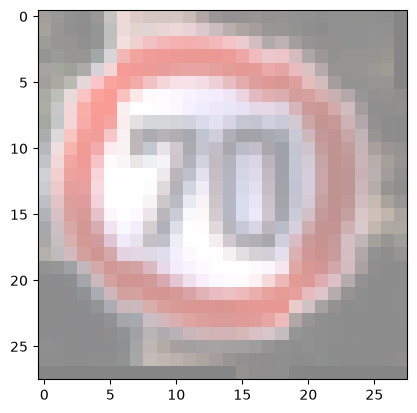

4 




In [22]:
for i in range(batch_size):
  imshow(images[i])
  print(labels[i].item(), "\n\n")


Define the neural network:

In [23]:
class Net(nn.Module):
    def __init__(
        self,
        img_size=28,
        in_channels=3,  # r, g, b
        n_maps=64,
        kernel_size=5,
        pool_size=2,
        n_classes=43,
    ):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, n_maps, kernel_size=kernel_size)
        size = img_size - kernel_size + 1
        self.pool1 = nn.MaxPool2d(pool_size)
        size = size // pool_size
        self.conv2 = nn.Conv2d(n_maps, n_maps, kernel_size=kernel_size)
        size = size - kernel_size + 1
        self.pool2 = nn.MaxPool2d(pool_size)
        size = size // pool_size

        self.fc2 = nn.Linear(n_maps * size * size, n_classes)

    def forward(self, x):
        x = self.pool1(F.elu(self.conv1(x)))
        x = self.pool2(F.elu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc2(x)

Instantiate the neural network and potentially move it to GPU:

In [24]:
net = Net()
if(gpu):
  net.to(device)
print(net)

Net(
  (conv1): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc2): Linear(in_features=1024, out_features=43, bias=True)
)


Define loss and optimization algorithm:

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001, eps=0.1)

These lines can be used to continue training:

In [26]:
cont = False
if cont:
  net.load_state_dict(torch.load('traffic_simple'))

Do the training:

In [27]:
no_epochs = 200
for epoch in range(no_epochs):  # Loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(generator_train, 0):
        # Get the inputs; data is a list of [inputs, labels]
        if (gpu):
          inputs, labels = data[0].to(device), data[1].to(device)
        else:
          inputs, labels = data
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Print statistics
        reporting_interval = 100
        running_loss += loss.item()
        if i % reporting_interval == reporting_interval-1:  # Print every reporting_interval mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / reporting_interval))
            running_loss = 0.0

print('Finished Training')

[1,   100] loss: 3.592
[1,   200] loss: 3.497
[1,   300] loss: 3.458
[2,   100] loss: 3.409
[2,   200] loss: 3.332
[2,   300] loss: 3.257
[3,   100] loss: 3.139
[3,   200] loss: 3.006
[3,   300] loss: 2.879
[4,   100] loss: 2.758
[4,   200] loss: 2.674
[4,   300] loss: 2.579
[5,   100] loss: 2.499
[5,   200] loss: 2.397
[5,   300] loss: 2.345
[6,   100] loss: 2.262
[6,   200] loss: 2.179
[6,   300] loss: 2.122
[7,   100] loss: 2.071
[7,   200] loss: 2.011
[7,   300] loss: 1.959
[8,   100] loss: 1.891
[8,   200] loss: 1.851
[8,   300] loss: 1.828
[9,   100] loss: 1.781
[9,   200] loss: 1.737
[9,   300] loss: 1.706
[10,   100] loss: 1.667
[10,   200] loss: 1.636
[10,   300] loss: 1.614
[11,   100] loss: 1.575
[11,   200] loss: 1.553
[11,   300] loss: 1.523
[12,   100] loss: 1.490
[12,   200] loss: 1.455
[12,   300] loss: 1.462
[13,   100] loss: 1.422
[13,   200] loss: 1.399
[13,   300] loss: 1.353
[14,   100] loss: 1.357
[14,   200] loss: 1.322
[14,   300] loss: 1.327
[15,   100] loss: 1

KeyboardInterrupt: 

Evaluate on test set:

In [ ]:
dataset_test = GTSRBTrafficSigns(train=False)
generator_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4)
print("Number of test patterns:", dataset_test.__len__())

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in generator_test:
        if (gpu):
          images, labels = data[0].to(device), data[1].to(device)
        else:
          images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on test images: %.2f %%' % (100 * correct / total))

Save network:

In [ ]:
torch.save(net.state_dict(), 'traffic_simple')